In [92]:
import matplotlib.pyplot as plt
#导包
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style('darkgrid')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
#导入数据与简单分析
sale_df0 = pd.read_csv('uniqlo.csv')
sale_df0.info()
print(sale_df0.city.unique().shape[0])
sale_df = sale_df0[sale_df0['order'] >= sale_df0['quant']]
sale_df['gender_group'].replace('Unkown', np.nan, inplace=True)
sale_df['age_group'].replace('Unkown', np.nan, inplace=True)
sale_df.dropna(inplace=True)
sale_df

In [ ]:
# 计算总体销售指标（总收入、总订单数、平均客单价）
##总收入
data1 = sale_df['revenue'].copy()
revenue_sum = sale_df['revenue'].sum()
print(f'总收入：{revenue_sum}元')

##总订单数
order_sum = sale_df['order'].sum()
print(f'总订单数为：{order_sum}')

## 平均客单价
aov = revenue_sum / order_sum
print(f'平均客单价：{aov}元')


In [ ]:
#分析城市分析销售，找出销售额最高的前五个城市
data0 = sale_df[['city', 'revenue']].copy()
data0_1 = data0.groupby(['city']).agg({'revenue': 'sum'}).reset_index().sort_values('revenue', ascending=False)
print(data0_1.head(5))

#可视化
plt.figure(figsize=[10, 5], dpi=100)
plt.bar(data0_1['city'], data0_1['revenue'])
plt.xlabel('city', fontsize=15)
plt.ylabel('revenue', fontsize=15)
plt.xticks(rotation=45)
plt.title('各城市销售额对比', fontsize=20)
plt.show()

  channel     revenue
0      线上   476658.25
1      线下  2119498.07


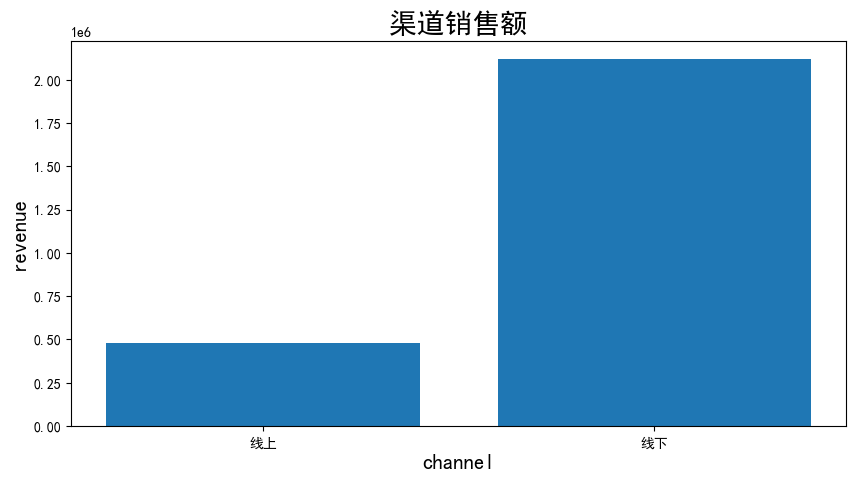

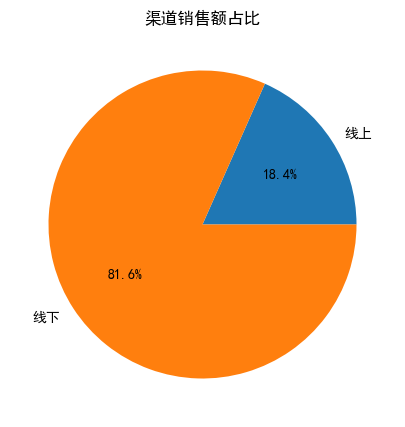

In [91]:
#线上线下的销售差异
data00 = sale_df[['channel', 'revenue']].copy()
data00_1 = data00.groupby('channel').agg({'revenue': 'sum'}).reset_index()
print(data00_1)

#可视化
plt.figure(figsize=[10, 5], dpi=100)
plt.bar(data00_1['channel'], data00_1['revenue'])
plt.xlabel('channel', fontsize=15)
plt.ylabel('revenue', fontsize=15)
plt.title('渠道销售额', fontsize=20)
plt.show()

#饼状图
plt.figure(figsize=[10, 5], dpi=100)
plt.pie(data00_1['revenue'], labels=data00_1['channel'], autopct='%1.1f%%')
plt.title('渠道销售额占比')
plt.show()

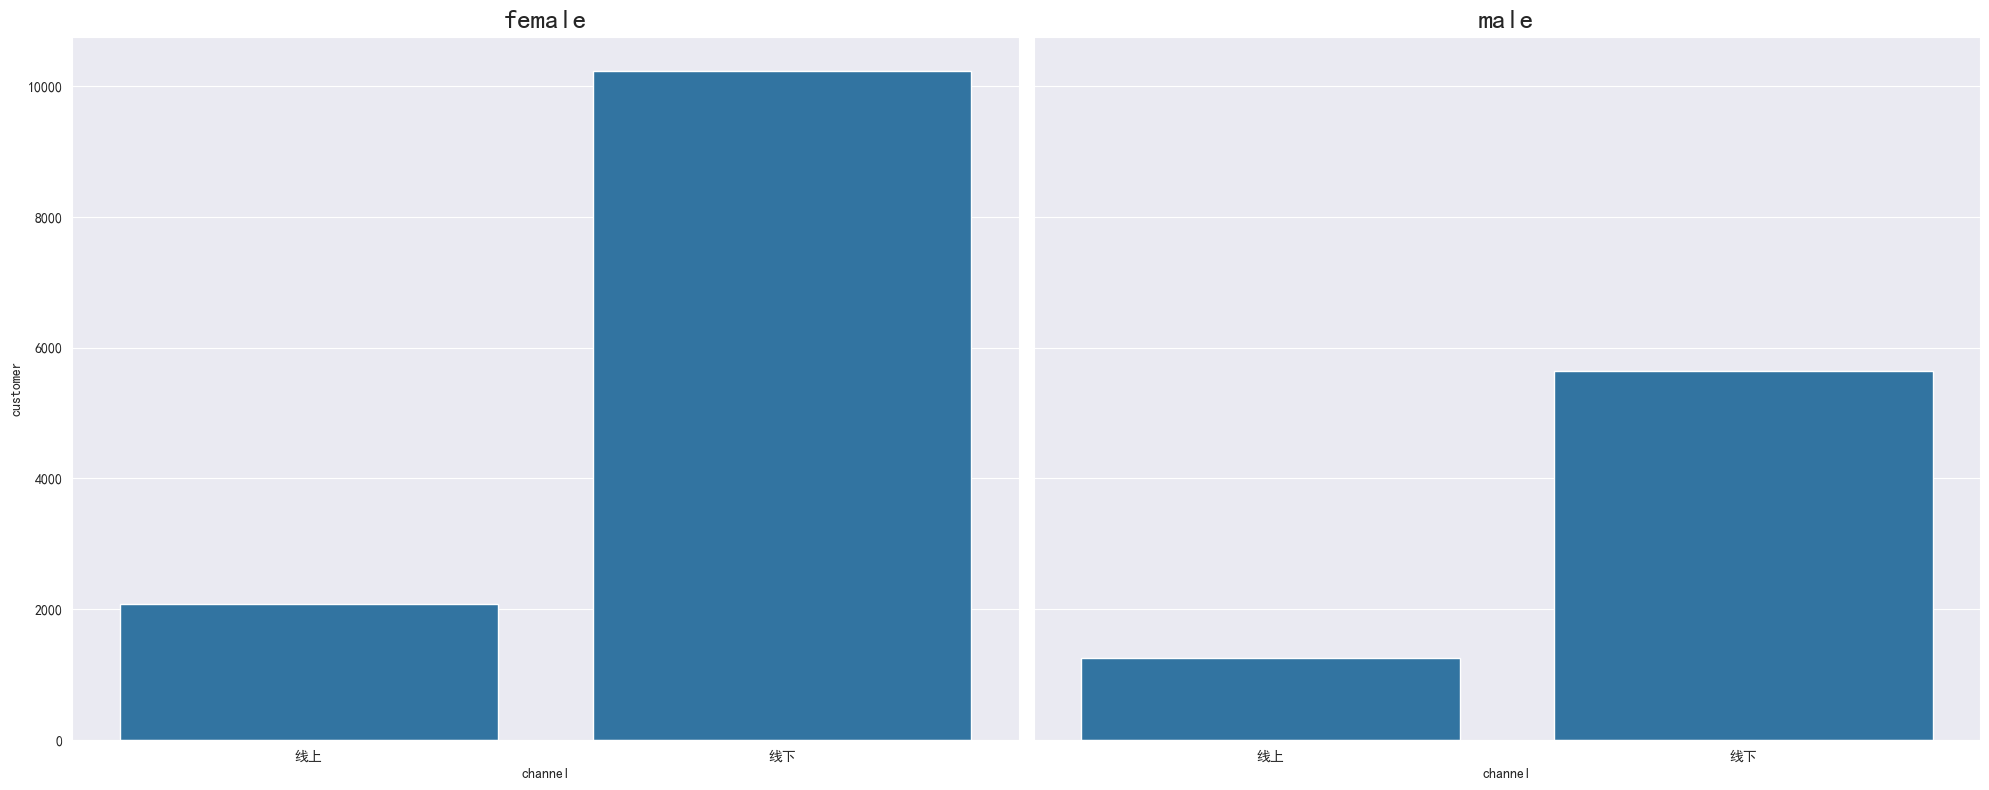

In [106]:
# 客户行为分析
## 分析不同性别组的购买偏好
#1.购买渠道
data2 = sale_df[['gender_group', 'channel', 'customer']].copy()
data2_filtered = data2[data2['gender_group'] != 'Unkown']
data2_1 = data2_filtered.groupby(['gender_group', 'channel']).agg({'customer': 'count'}).reset_index()
data2_1

#可视化
data_2_1 = data2_1[data2_1['gender_group'] == 'Female']
data_2_2 = data2_1[data2_1['gender_group'] == 'Male']
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(20, 8), dpi=100)
sns.barplot(x='channel', y='customer', data=data_2_1, ax=axes[0])
axes[0].set_xlabel('channel')
axes[0].set_ylabel('customer')
axes[0].set_title('female', fontsize=20)
sns.barplot(x='channel', y='customer', data=data_2_2, ax=axes[1])
axes[1].set_title('male', fontsize=20)
plt.tight_layout()
plt.show()


C:\Users\icyw\AppData\Local\Temp\ipykernel_8000\74524355.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data3['gender_group'].replace('Unkown',np.nan,inplace=True)
C:\Users\icyw\AppData\Local\Temp\ipykernel_8000\74524355.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

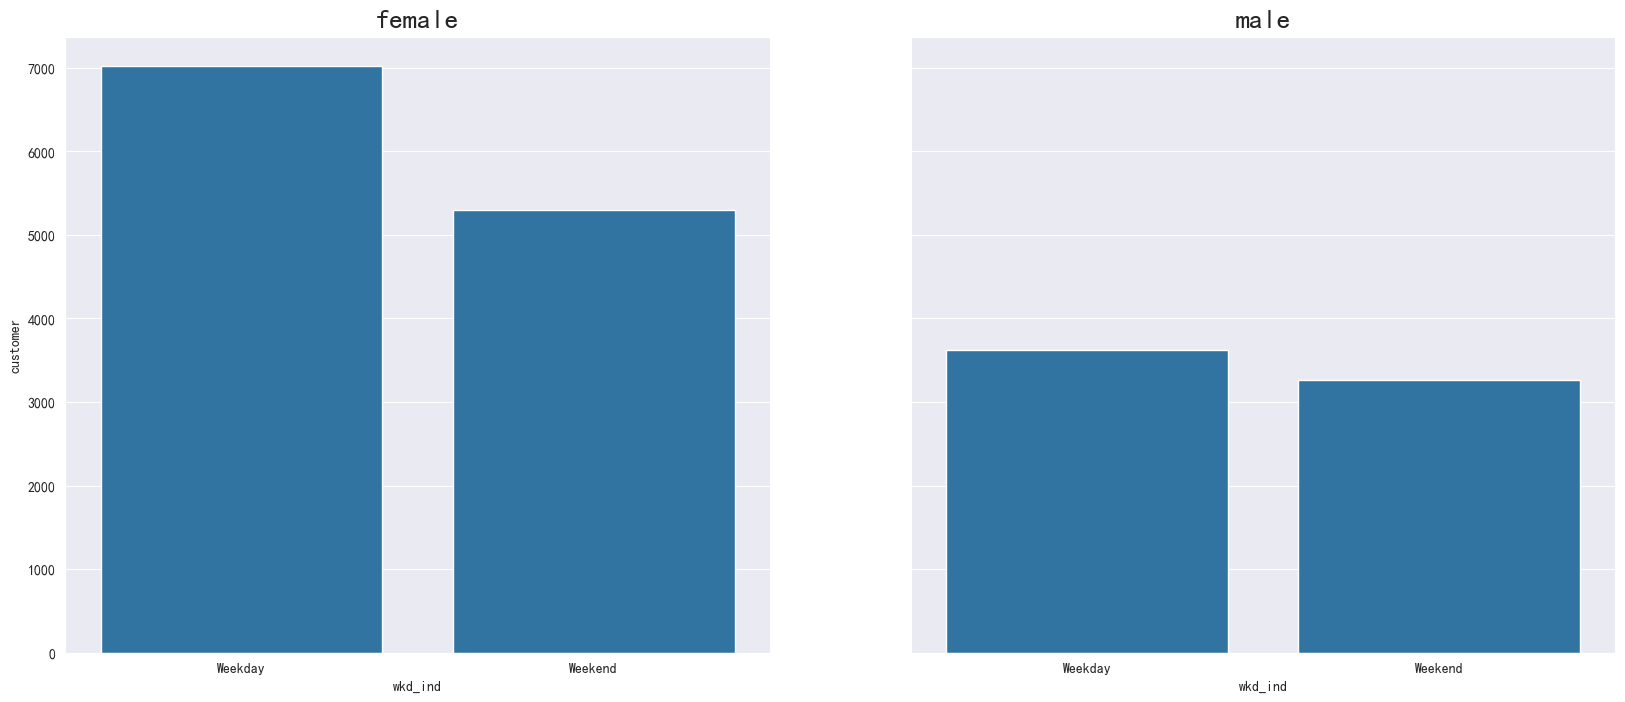

In [109]:
#2.购买时间
data3 = sale_df[['gender_group', 'wkd_ind', 'customer']].copy()
data3['gender_group'].replace('Unkown', np.nan, inplace=True)
data3['wkd_ind'].replace('Unkown', np.nan, inplace=True)
data3.dropna(inplace=True)
data3_1 = data3.groupby(['gender_group', 'wkd_ind']).agg({'customer': 'count'}).reset_index()
data3_1

#可视化
data3_1_1 = data3_1[data3_1['gender_group'] == 'Female']
data3_1_2 = data3_1[data3_1['gender_group'] == 'Male']
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(20, 8), dpi=100)
sns.barplot(x='wkd_ind', y='customer', data=data3_1_1, ax=axes[0])
sns.barplot(x='wkd_ind', y='customer', data=data3_1_2, ax=axes[1])
axes[0].set_xlabel('wkd_ind')
axes[0].set_ylabel('customer')
axes[0].set_title('female', fontsize=20)
axes[1].set_title('male', fontsize=20)
plt.show()



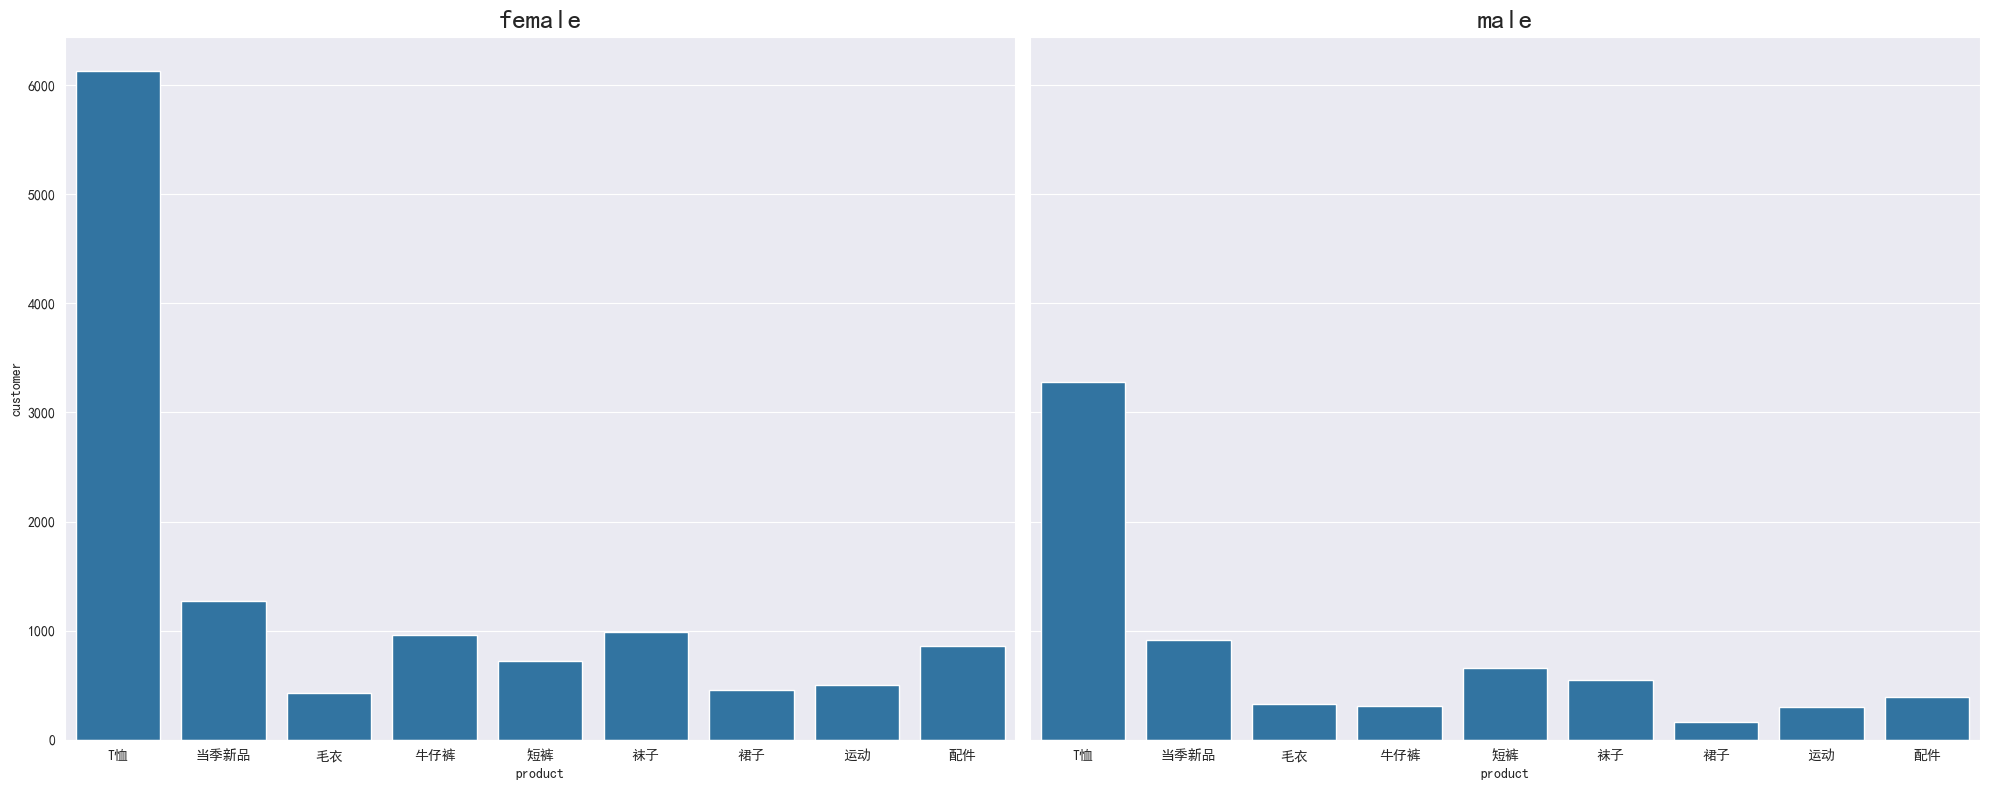

In [113]:
#3.购买产品
data4 = sale_df[['product', 'gender_group', 'customer']].copy()
data4_filtered = data4[data4['gender_group'] != 'Unkown']
data4_1 = data4_filtered.groupby(['gender_group', 'product']).agg({'customer': 'count'}).reset_index()
data4_1

#可视化
data4_1_1 = data4_1[data4_1['gender_group'] == 'Female']
data4_1_2 = data4_1[data4_1['gender_group'] == 'Male']
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(20, 8), dpi=100)
sns.barplot(x='product', y='customer', data=data4_1_1, ax=axes[0])
sns.barplot(x='product', y='customer', data=data4_1_2, ax=axes[1])
axes[0].set_xlabel('product')
axes[0].set_ylabel('customer')
axes[0].set_title('female', fontsize=20)
axes[1].set_title('male', fontsize=20)
plt.tight_layout()
plt.show()


In [114]:
##分析不同年龄组的购买偏好
#1.购买渠道
data5 = sale_df[['channel', 'age_group', 'customer']].copy()

data5_filtered = data5[data5['age_group'] != 'Unkown']
data5_1 = data5_filtered.groupby(['age_group', 'channel']).agg({'customer': 'count'}).sort_values(
    ['age_group', 'channel'], ascending=True)
data5_1

#后续 增加百分比 绘图

customer
age_group channel          
20-24     线上            487
          线下           2396
25-29     线上            694
          线下           2942
30-34     线上            652
          线下           3121
35-39     线上            532
          线下           2688
40-44     线上            305
          线下           1434
45-49     线上            174
          线下            801
50-54     线上             84
          线下            490
55-59     线上             61
          线下            374
<20       线上             95
          线下            481
>=60      线上            247
          线下           1150

In [115]:
#2.购买时间
data6 = sale_df[['age_group', 'wkd_ind', 'customer']].copy()
data6_filtered = data6[data6['age_group'] != 'Unkown']
data6_1 = data6_filtered.groupby(['age_group', 'wkd_ind']).agg({'customer': 'count'})
data6_1

customer
age_group wkd_ind          
20-24     Weekday      1610
          Weekend      1273
25-29     Weekday      1938
          Weekend      1698
30-34     Weekday      2039
          Weekend      1734
35-39     Weekday      1792
          Weekend      1428
40-44     Weekday       975
          Weekend       764
45-49     Weekday       565
          Weekend       410
50-54     Weekday       345
          Weekend       229
55-59     Weekday       282
          Weekend       153
<20       Weekday       313
          Weekend       263
>=60      Weekday       788
          Weekend       609

In [ ]:
#3.购买产品
data7 = sale_df[['age_group', 'product', 'customer']].copy()
data7_filtered = data7[data7['age_group'] != 'Unkown']
data7_1 = data7_filtered.groupby(['age_group', 'product']).agg({'customer': 'count'})
data7_1

In [ ]:
#最受欢迎的产品
data8 = sale_df[['product', 'customer']].copy()
data8_1 = data8.groupby('product').agg({'customer': 'count'})
data8_1.nlargest(5, 'customer')

In [ ]:
#计算各产品的毛利率
data9 = sale_df[['product', 'revenue', 'unit_cost', 'quant']]
data9['cost'] = data9['unit_cost'] * data9['quant']
data9_1 = data9.groupby(['product']).agg({'revenue': 'sum', 'cost': 'sum'})

data9_1['gross_margin_rate'] = (data9_1['revenue'] - data9_1['cost']) / data9_1['revenue'] * 100
data9_1

In [ ]:
#分析各城市的产品偏好差异
data10 = sale_df[['product', 'city', 'customer']].copy()
data10_1 = data10.groupby(['city', 'product']).agg({'customer': 'count'})
data10_1

In [ ]:
#找出销售额最高的门店组合
data11 = sale_df[['city', 'channel', 'revenue']].copy()
data11_1 = data11.groupby(['city', 'channel']).agg({'revenue': 'sum'})
data11_1.nlargest(5, 'revenue')

In [ ]:
#创建销售数据透视表
##1.订单数量
data12 = sale_df[['city', 'product', 'order']].copy()
data12.pivot_table(index='city', columns='product', values='order', aggfunc='sum')

In [ ]:
##2.收益
data13 = sale_df[['city', 'product', 'revenue']].copy()
data13.pivot_table(index='city', columns='product', values='revenue', aggfunc='sum')

In [ ]:
##3.毛利率
data14 = sale_df[['city', 'product', 'revenue', 'unit_cost', 'quant']].copy()
data14['cost'] = data14['unit_cost'] * data14['quant']
data14_1 = data14.groupby(['city', 'product']).agg({'revenue': 'sum', 'cost': 'sum'})
data14_1['gross_margin_rate'] = (data14_1['revenue'] - data14_1['cost']) / data14_1['revenue'] * 100
data14_1['gross_margin_rate'] = data14_1['gross_margin_rate'].round(2)
data14_1.pivot_table(index='city', columns='product', values='gross_margin_rate')

